In [4]:
import subprocess

# Step 1: Create the PHREEQC input file
input_file_content = """

TITLE Example 5.--Add oxygen, equilibrate with pyrite, calcite, and goethite.
SOLUTION 1  PURE WATER
        pH      7.0
        temp    25.0
EQUILIBRIUM_PHASES 1
        Pyrite          0.0
        Goethite        0.0
        Calcite         0.0
        CO2(g)         -3.5
        Gypsum          0.0     0.0
REACTION 1
        O2      1.0
        NaCl    0.5
        0.0     0.001   0.005   0.01   0.03   0.05
SELECTED_OUTPUT
        -file   ex5.sel
        -total  Cl
        -si     Gypsum
        -equilibrium_phases  pyrite goethite calcite CO2(g) gypsum
 END   

"""

#+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# ========================== NO TOCAR ESTA PARTE ================================================
#+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
input_file_name = "phreeqc_input_file.pqi"
with open(input_file_name, "w") as file:
    file.write(input_file_content)
print(f"PHREEQC input file '{input_file_name}' created successfully.")

# Step 2: Run PHREEQC using subprocess
output_file_name = "phreeqc_output.txt"
database_file = "/opt/shared/PHREEQC_code/phreeqc-3.8.6-17100/database/phreeqc.dat"  # Update the path if necessary
phreeqc_executable = "/opt/shared/PHREEQC_code/phreeqc-3.8.6-17100/src/phreeqc"  # Use "phreeqc.exe" on Windows, or the full path to the executable

# Run PHREEQC
try:
    subprocess.run([phreeqc_executable, input_file_name, output_file_name, database_file], check=True)
    print(f"PHREEQC run completed. Output saved in '{output_file_name}'.")
except subprocess.CalledProcessError as e:
    print(f"PHREEQC execution failed: {e}")
    
# Display the contents of the output file, ignoring problematic characters
try:
    with open(output_file_name, "r", encoding="utf-8", errors="ignore") as output_file:
        output_content = output_file.read()
    print("PHREEQC Output:\n")
    print(output_content)
except FileNotFoundError:
    print(f"Output file '{output_file_name}' not found.")    

#+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# ================================================================================================
#+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

PHREEQC input file 'phreeqc_input_file.pqi' created successfully.
PHREEQC run completed. Output saved in 'phreeqc_output.txt'.
PHREEQC Output:

   Input file: phreeqc_input_file.pqi
  Output file: phreeqc_output.txt
Database file: /opt/shared/PHREEQC_code/phreeqc-3.8.6-17100/database/phreeqc.dat

------------------
Reading data base.
------------------

	SOLUTION_MASTER_SPECIES
	SOLUTION_SPECIES
	PHASES
	GAS_BINARY_PARAMETERS
	EXCHANGE_MASTER_SPECIES
	EXCHANGE_SPECIES
	SURFACE_MASTER_SPECIES
	SURFACE_SPECIES
	MEAN_GAMMAS
	RATES
	END
------------------------------------
Reading input data for simulation 1.
------------------------------------

	TITLE Example 5.--Add oxygen, equilibrate with pyrite, calcite, and goethite.
	SOLUTION 1  PURE WATER
	        pH      7.0
	        temp    25.0
	EQUILIBRIUM_PHASES 1
	        Pyrite          0.0
	        Goethite        0.0
	        Calcite         0.0
	        CO2(g)         -3.5
	        Gypsum          0.0     0.0
	REACTION 1
	        O2     

Input file: phreeqc_input_file.pqi

Output file: phreeqc_output.txt

Database file: /opt/shared/PHREEQC_code/phreeqc-3.8.6-17100/database/phreeqc.dat

              █▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀█
              ║                                            ║
              ║             * PHREEQC-3.8.6 *              ║
              ║                                            ║
              ║      A hydrogeochemical transport model    ║
              ║                                            ║
              ║                    by                      ║
              ║       D.L. Parkhurst and C.A.J. Appelo     ║
              ║                                            ║
              ║              January  7, 2025              ║
              █▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄���█


Initializing...                                                                 

End of Run after 0.010479 Seconds.


/tmp/ipykernel_27120/3891247436.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv('ex2.sel', delim_whitespace=True, skiprows=[1])


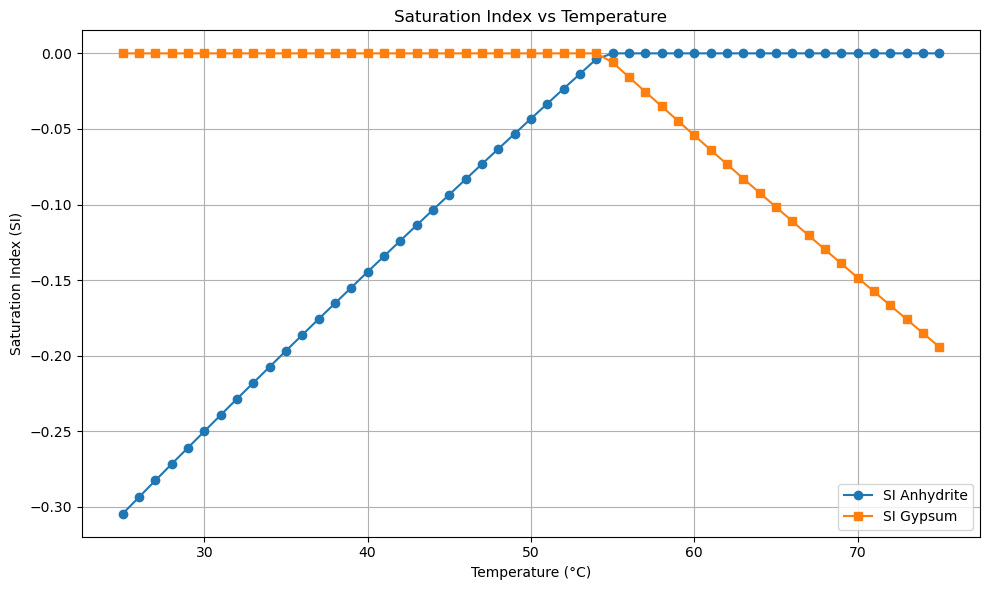

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the file while skipping the first numerical row (index 1)
df = pd.read_csv('ex2.sel', delim_whitespace=True, skiprows=[1])

# Plot saturation index of anhydrite and gypsum vs temperature
plt.figure(figsize=(10, 6))
plt.plot(df['temp'], df['si_anhydrite'], label='SI Anhydrite', marker='o')
plt.plot(df['temp'], df['si_gypsum'], label='SI Gypsum', marker='s')

# Add labels and title
plt.xlabel('Temperature (°C)')
plt.ylabel('Saturation Index (SI)')
plt.title('Saturation Index vs Temperature')
plt.grid(True)
plt.legend()
plt.tight_layout()

# Show the plot
plt.show()
